In [1]:
import pandas as pd
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=AdventureWorks2025;"
    "Trusted_Connection=yes;"
)

query = "SELECT * FROM dbo.vw_fact_sales;"
df = pd.read_sql(query, conn)

print(df.shape)
df.head()

C:\Users\hisuk\AppData\Local\Temp\ipykernel_20656\2536646386.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(121317, 14)


,SalesOrderID,SalesOrderDetailID,CustomerID,TerritoryID,ProductID,OrderDate,OrderQty,UnitPrice,UnitPriceDiscount,Revenue,ProductName,ProductCategory,TerritoryName,TerritoryGroup
0,43659,1,29825,5,776,2022-05-30,1,2024.994,0.0,2024.994,"Mountain-100 Black, 42",Bikes,Southeast,North America
1,43659,2,29825,5,777,2022-05-30,3,2024.994,0.0,6074.982,"Mountain-100 Black, 44",Bikes,Southeast,North America
2,43659,3,29825,5,778,2022-05-30,1,2024.994,0.0,2024.994,"Mountain-100 Black, 48",Bikes,Southeast,North America
3,43659,4,29825,5,771,2022-05-30,1,2039.994,0.0,2039.994,"Mountain-100 Silver, 38",Bikes,Southeast,North America
4,43659,5,29825,5,772,2022-05-30,1,2039.994,0.0,2039.994,"Mountain-100 Silver, 42",Bikes,Southeast,North America


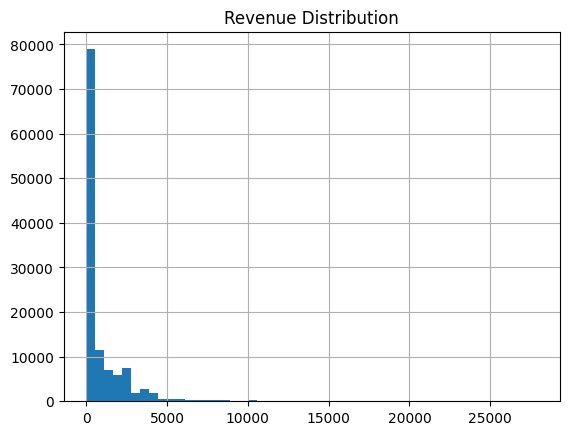

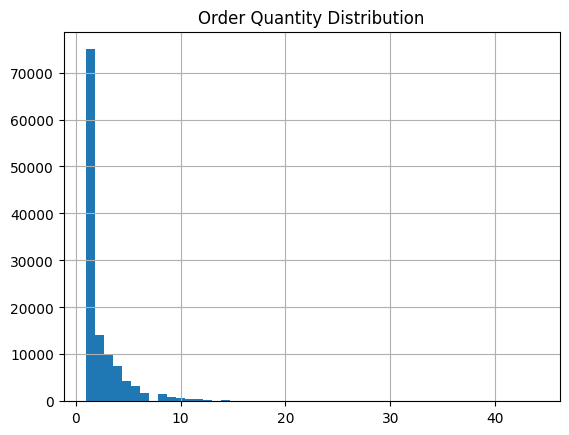

In [3]:
import matplotlib.pyplot as plt

df["Revenue"].hist(bins=50)
plt.title("Revenue Distribution")
plt.show()

df["OrderQty"].hist(bins=50)
plt.title("Order Quantity Distribution")
plt.show()

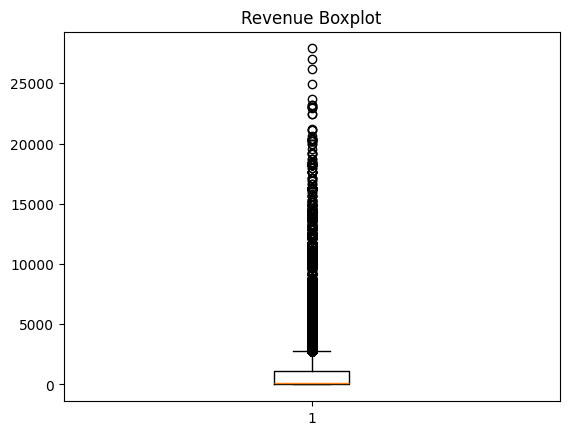

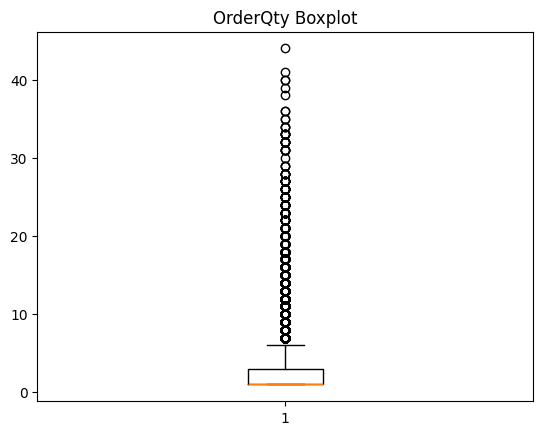

In [4]:
plt.boxplot(df["Revenue"])
plt.title("Revenue Boxplot")
plt.show()

plt.boxplot(df["OrderQty"])
plt.title("OrderQty Boxplot")
plt.show()

In [5]:
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Revenue"] < lower) | (df["Revenue"] > upper)]

print("Outlier count:", len(outliers))


Outlier count: 10737


In [6]:
outliers.sort_values(by="Revenue", ascending=False).head(10)

,SalesOrderID,SalesOrderDetailID,CustomerID,TerritoryID,ProductID,OrderDate,OrderQty,UnitPrice,UnitPriceDiscount,Revenue,ProductName,ProductCategory,TerritoryName,TerritoryGroup
55438,55282,55439,29641,4,954,2024-08-29,26,1192.0350,0.10,27893.619000,"Touring-1000 Yellow, 46",Bikes,Southwest,North America
915,43884,916,29861,3,772,2022-06-30,14,1971.9942,0.02,27055.760424,"Mountain-100 Silver, 42",Bikes,Central,North America
36826,51131,36827,29641,4,969,2024-05-29,21,1311.2385,0.05,26159.208075,"Touring-1000 Blue, 60",Bikes,Southwest,North America
804,43875,805,29624,5,775,2022-06-30,13,1957.4942,0.02,24938.476108,"Mountain-100 Black, 38",Bikes,Southeast,North America
61114,57054,61115,29564,7,966,2024-09-29,19,1311.2385,0.05,23667.854925,"Touring-1000 Blue, 46",Bikes,France,Europe
4812,44795,4813,29562,4,773,2022-10-30,12,1971.9942,0.02,23190.651792,"Mountain-100 Silver, 44",Bikes,Southwest,North America
802,43875,803,29624,5,773,2022-06-30,12,1971.9942,0.02,23190.651792,"Mountain-100 Silver, 44",Bikes,Southeast,North America
3487,44534,3488,29515,6,777,2022-09-30,12,1957.4942,0.02,23020.131792,"Mountain-100 Black, 44",Bikes,Canada,North America
9172,46090,9173,29507,5,775,2023-03-30,12,1957.4942,0.02,23020.131792,"Mountain-100 Black, 38",Bikes,Southeast,North America
3241,44518,3242,29624,5,776,2022-09-30,12,1957.4942,0.02,23020.131792,"Mountain-100 Black, 42",Bikes,Southeast,North America


In [7]:
df["ProductCategory"].value_counts()

ProductCategory
Accessories    41194
Bikes          40031
Clothing       21394
Components     18698
Name: count, dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.duplicated(subset=["SalesOrderID", "ProductID"], keep=False)]

,SalesOrderID,SalesOrderDetailID,CustomerID,TerritoryID,ProductID,OrderDate,OrderQty,UnitPrice,UnitPriceDiscount,Revenue,ProductName,ProductCategory,TerritoryName,TerritoryGroup
